# Actúa DeUna!

## Importación de librerías

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

## Importación del Datos

### Lectura

In [172]:
from google.colab import drive
drive.mount('/content/drive/')

df = pd.read_csv("/content/drive/MyDrive/DeUna/deuna_churn_Ecuador_dataset_.csv")

print("Datos cargados:")
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Datos cargados:


,merchant_id,tipo_de_negocio,provincia,meses_historial,ticket_promedio_usd,frecuencia_anual_txn,dias_desde_ultima_txn,conteo_txn_ultimos_30d,conteo_txn_fallidas_30d,tickets_soporte_30d,variacion_volumen_pct,dias_desde_ultimo_login,rentabilidad_app_usd_30d,target_churn_30d
0,M-CALD-00001,Gastronomía Local,Pichincha,9,19.85,1227,2,143,3,0,0.041,3,70.66,0
1,M-CALD-00002,Servicios Profesionales y Serenatas,Santa Elena,4,15.06,420,1,107,2,0,0.038,3,40.09,0
2,M-CALD-00003,Gastronomía Local,Manabí,4,8.93,155,19,11,0,0,-0.455,41,2.46,0
3,M-CALD-00004,Gastronomía Local,Guayas,3,24.19,281,1,100,1,1,-0.001,2,57.88,0
4,M-CALD-00005,Agricultura Urbana y Canastas a Domicilio,Pichincha,10,20.67,540,14,17,3,0,-0.730,27,8.48,1


### Limpieza de categóricos

In [173]:
print("Shape:", df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

Shape: (5000, 14)

Tipos de datos:
merchant_id                  object
tipo_de_negocio              object
provincia                    object
meses_historial               int64
ticket_promedio_usd         float64
frecuencia_anual_txn          int64
dias_desde_ultima_txn         int64
conteo_txn_ultimos_30d        int64
conteo_txn_fallidas_30d       int64
tickets_soporte_30d           int64
variacion_volumen_pct       float64
dias_desde_ultimo_login       int64
rentabilidad_app_usd_30d    float64
target_churn_30d              int64
dtype: object

Valores nulos:
merchant_id                 0
tipo_de_negocio             0
provincia                   0
meses_historial             0
ticket_promedio_usd         0
frecuencia_anual_txn        0
dias_desde_ultima_txn       0
conteo_txn_ultimos_30d      0
conteo_txn_fallidas_30d     0
tickets_soporte_30d         0
variacion_volumen_pct       0
dias_desde_ultimo_login     0
rentabilidad_app_usd_30d    0
target_churn_30d            0
dtype: int6

### Separar Variables

In [174]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna("Unknown", inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.lower().str.strip()

print("Limpieza completada")
df.head()

Limpieza completada


/tmp/ipykernel_3907/153487253.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)
/tmp/ipykernel_3907/153487253.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

,merchant_id,tipo_de_negocio,provincia,meses_historial,ticket_promedio_usd,frecuencia_anual_txn,dias_desde_ultima_txn,conteo_txn_ultimos_30d,conteo_txn_fallidas_30d,tickets_soporte_30d,variacion_volumen_pct,dias_desde_ultimo_login,rentabilidad_app_usd_30d,target_churn_30d
0,m-cald-00001,gastronomía local,pichincha,9,19.85,1227,2,143,3,0,0.041,3,70.66,0
1,m-cald-00002,servicios profesionales y serenatas,santa elena,4,15.06,420,1,107,2,0,0.038,3,40.09,0
2,m-cald-00003,gastronomía local,manabí,4,8.93,155,19,11,0,0,-0.455,41,2.46,0
3,m-cald-00004,gastronomía local,guayas,3,24.19,281,1,100,1,1,-0.001,2,57.88,0
4,m-cald-00005,agricultura urbana y canastas a domicilio,pichincha,10,20.67,540,14,17,3,0,-0.730,27,8.48,1


### Atípicos

In [175]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

meses_historial: 0 outliers
ticket_promedio_usd: 202 outliers
frecuencia_anual_txn: 87 outliers
dias_desde_ultima_txn: 790 outliers
conteo_txn_ultimos_30d: 4 outliers
conteo_txn_fallidas_30d: 928 outliers
tickets_soporte_30d: 446 outliers
variacion_volumen_pct: 606 outliers
dias_desde_ultimo_login: 963 outliers
rentabilidad_app_usd_30d: 47 outliers
target_churn_30d: 0 outliers


### Estadísticas

In [176]:
df.describe()

,meses_historial,ticket_promedio_usd,frecuencia_anual_txn,dias_desde_ultima_txn,conteo_txn_ultimos_30d,conteo_txn_fallidas_30d,tickets_soporte_30d,variacion_volumen_pct,dias_desde_ultimo_login,rentabilidad_app_usd_30d,target_churn_30d
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7.556600,19.438830,763.494200,4.723200,90.435600,5.573800,0.616600,-0.112977,7.494800,38.037212,0.307000
std,2.860495,9.576906,452.165852,7.054653,53.447933,8.812292,1.241416,0.264193,11.285949,27.245434,0.461296
min,3.000000,5.000000,-184.000000,0.000000,-25.000000,0.000000,0.000000,-1.070000,0.000000,-36.310000,0.000000
25%,5.000000,12.150000,417.750000,1.000000,48.000000,1.000000,0.000000,-0.183000,1.000000,15.867500,0.000000
50%,8.000000,18.250000,668.000000,2.000000,94.000000,2.000000,0.000000,0.007500,3.000000,34.075000,0.000000
75%,10.000000,23.962500,1018.250000,5.000000,129.000000,3.000000,1.000000,0.062000,5.000000,55.380000,1.000000
max,12.000000,49.970000,2873.000000,27.000000,269.000000,34.000000,9.000000,0.219000,44.000000,178.540000,1.000000


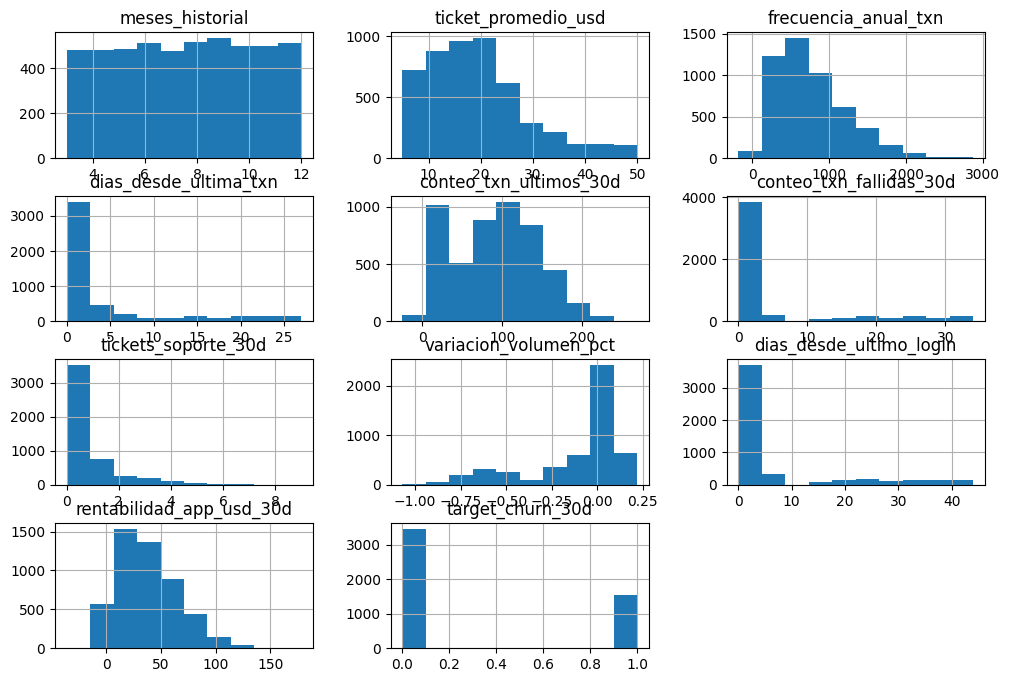

In [177]:
df.hist(figsize=(12, 8))
plt.show()

### Matriz de correlación (Mapa de Calor)

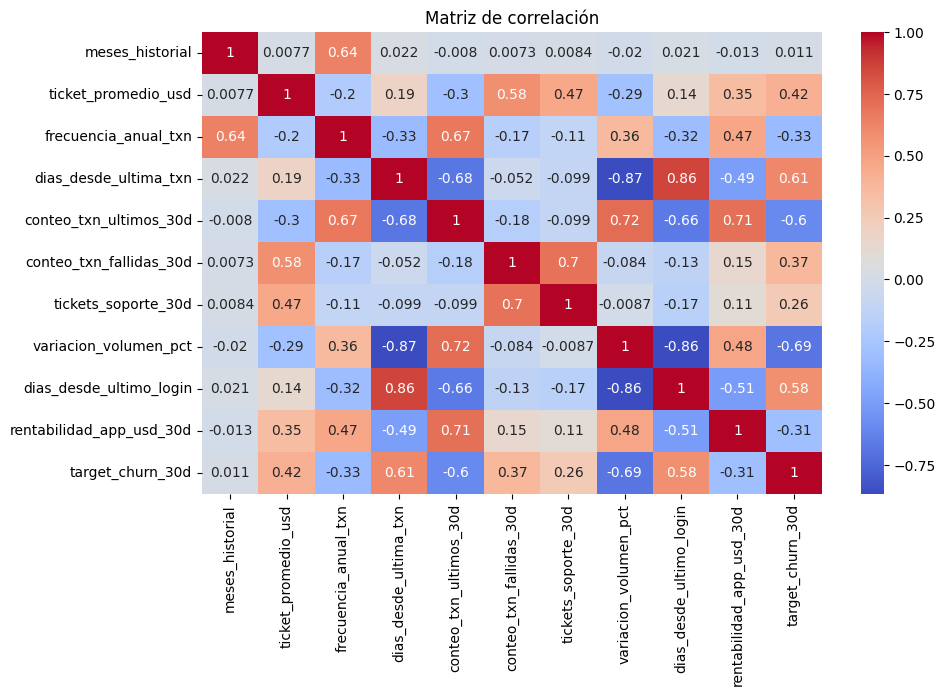

In [178]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### Nuevas Variables

In [179]:
for col in df.columns:
    if "date" in col or "fecha" in col:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[f"{col}_year"] = df[col].dt.year
        df[f"{col}_month"] = df[col].dt.month

if 'price' in df.columns and 'quantity' in df.columns:
    df['total'] = df['price'] * df['quantity']

print("Nuevas features:")
df.head()

Nuevas features:


,merchant_id,tipo_de_negocio,provincia,meses_historial,ticket_promedio_usd,frecuencia_anual_txn,dias_desde_ultima_txn,conteo_txn_ultimos_30d,conteo_txn_fallidas_30d,tickets_soporte_30d,variacion_volumen_pct,dias_desde_ultimo_login,rentabilidad_app_usd_30d,target_churn_30d
0,m-cald-00001,gastronomía local,pichincha,9,19.85,1227,2,143,3,0,0.041,3,70.66,0
1,m-cald-00002,servicios profesionales y serenatas,santa elena,4,15.06,420,1,107,2,0,0.038,3,40.09,0
2,m-cald-00003,gastronomía local,manabí,4,8.93,155,19,11,0,0,-0.455,41,2.46,0
3,m-cald-00004,gastronomía local,guayas,3,24.19,281,1,100,1,1,-0.001,2,57.88,0
4,m-cald-00005,agricultura urbana y canastas a domicilio,pichincha,10,20.67,540,14,17,3,0,-0.730,27,8.48,1


### Datos Escalados

In [180]:
numeric_cols = df.select_dtypes(include=np.number).columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Datos escalados")
df.head()

Datos escalados


,merchant_id,tipo_de_negocio,provincia,meses_historial,ticket_promedio_usd,frecuencia_anual_txn,dias_desde_ultima_txn,conteo_txn_ultimos_30d,conteo_txn_fallidas_30d,tickets_soporte_30d,variacion_volumen_pct,dias_desde_ultimo_login,rentabilidad_app_usd_30d,target_churn_30d
0,m-cald-00001,gastronomía local,pichincha,0.504648,0.042938,1.025182,-0.386053,0.983568,-0.292099,-0.496741,0.582876,-0.398305,1.197487,-0.665584
1,m-cald-00002,servicios profesionales y serenatas,santa elena,-1.243475,-0.457274,-0.759740,-0.527818,0.309948,-0.405588,-0.496741,0.571520,-0.398305,0.075352,-0.665584
2,m-cald-00003,gastronomía local,manabí,-1.243475,-1.097419,-1.345867,2.023945,-1.486373,-0.632566,-0.496741,-1.294724,2.969050,-1.305935,-0.665584
3,m-cald-00004,gastronomía local,guayas,-1.593100,0.496157,-1.067180,-0.527818,0.178966,-0.519077,0.308872,0.423886,-0.486920,0.728371,-0.665584
4,m-cald-00005,agricultura urbana y canastas a domicilio,pichincha,0.854273,0.128569,-0.494324,1.315122,-1.374103,-0.292099,-0.496741,-2.335733,1.728446,-1.084959,1.502441


### Guardar nuevo archivo

In [181]:
output_path = "/content/drive/MyDrive/DeUna/data_procesada.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig", sep=';', decimal=',')

print(f"Archivo guardado en {output_path}")

Archivo guardado en /content/drive/MyDrive/DeUna/data_procesada.csv


## Aplicación del Modelo de ML (Random Forest)

In [182]:
# 1. Cargar el dataset ORIGINAL
archivo_original = '/content/drive/MyDrive/DeUna/deuna_churn_Ecuador_dataset_.csv'
df = pd.read_csv(archivo_original)

# Limpieza preventiva del ID para asegurar que no haya espacios ocultos
df['merchant_id'] = df['merchant_id'].astype(str).str.strip()

In [183]:
# 2. INGENIERÍA DE VARIABLES
if 'distancia_capital_km' not in df.columns:
    np.random.seed(1)
    df['distancia_capital_km'] = np.random.exponential(scale=30, size=len(df)).clip(0, 150)

# Calcular las medias provinciales obligatoriamente (EL UMBRAL SEGMENTADO)
medias_provinciales = df.groupby('provincia')[['conteo_txn_fallidas_30d', 'tickets_soporte_30d']].transform('mean')
df['media_fallidas_provincia'] = medias_provinciales['conteo_txn_fallidas_30d']
df['media_tickets_provincia'] = medias_provinciales['tickets_soporte_30d']

In [184]:
# 3. ENTRENAMIENTO DEL MODELO
features = ['conteo_txn_fallidas_30d', 'tickets_soporte_30d', 'ticket_promedio_usd', 'rentabilidad_app_usd_30d', 'distancia_capital_km']
X = pd.get_dummies(df[features + ['provincia']], columns=['provincia'], drop_first=True)

df['target_churn_bin'] = (df['target_churn_30d'] > 0).astype(int)
y = df['target_churn_bin']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=150, random_state=42)

In [185]:
# 4. CÁLCULO DE PROBABILIDADES
df['probabilidad_inactividad_pct'] = modelo_rf.predict_proba(X)[:, 1]
# Formato porcentual para visualización en el archivo final
df['probabilidad_inactividad'] = (df['probabilidad_inactividad_pct']).round(5).astype(str).str.replace('.', ',')

In [186]:
# 5. DIAGNÓSTICO DEL PROBLEMA Y ASIGNACIÓN DE ESTRATEG
def diagnostico_y_estrategia(row):
    prob = row['probabilidad_inactividad_pct']
    fallas = row['conteo_txn_fallidas_30d']
    media_fallas = row['media_fallidas_provincia']
    tickets = row['tickets_soporte_30d']
    media_tickets = row['media_tickets_provincia']
    rentable = row['rentabilidad_app_usd_30d'] > 0
    es_lejos = row['distancia_capital_km'] > 50

    # Lógica de Fricción: Comparamos el umbral contra la media de su provincia
    friccion_alta = (fallas > media_fallas) or (tickets > media_tickets)

    # A. IDENTIFICACIÓN DEL PROBLEMA
    if prob < 0.40:
        problema = "Sin Problemas (Operación Saludable)"
    elif friccion_alta:
        if fallas > media_fallas and tickets > media_tickets:
            problema = "Fricción Crítica (Fallas técnicas masivas y quejas de soporte)"
        elif fallas > media_fallas:
            problema = "Problema de Infraestructura (Fallas superan la media local)"
        else:
            problema = "Insatisfacción Operativa (Alta demanda de soporte sin uso)"
    else:
        problema = "Abandono Silencioso (Uso de competencia o efectivo)"

    # B. ASIGNACIÓN DE ESTRATEGIA
    if prob < 0.40:
        estrategia = "Notificación de marketing: 'DeUna te extraña'"
    elif rentable:
        if friccion_alta:
            estrategia = "Llamada de soporte prioritaria" if es_lejos else "Visita técnica VIP"
        else:
            estrategia = "Promoción/Beneficios en línea"
    else:
        estrategia = "Instructivo automatizado" if friccion_alta else "Notificación de marketing: 'DeUna te extraña'"

    return pd.Series([problema, estrategia])

# Aplicamos la función para generar ambas columnas
df[['problema_identificado', 'estrategia_asignada']] = df.apply(diagnostico_y_estrategia, axis=1)

In [187]:
# 6. ORDENAMIENTO Y PREPARACIÓN DEL ENTREGABLE FINAL
# Ordenamos matemáticamente por la probabilidad de riesgo y la rentabilidad
df_final = df.sort_values(by=['probabilidad_inactividad_pct', 'rentabilidad_app_usd_30d'], ascending=[False, False])

# Definimos una lista simple con las columnas exactas que queremos conservar
columnas_entregable = [
    'merchant_id',
    'tipo_de_negocio',
    'provincia',
    'problema_identificado',
    'dias_desde_ultima_txn',
    'probabilidad_inactividad',
    'conteo_txn_fallidas_30d',
    'tickets_soporte_30d',
    'rentabilidad_app_usd_30d',
    'estrategia_asignada'
]

# Filtramos el DataFrame dejando los nombres intactos
df_final = df_final[columnas_entregable]

In [188]:
# 7. GUARDAR ARCHIVO
nombre_archivo_salida = '/content/drive/MyDrive/DeUna/dataset_retencion_deuna.csv'
df_final.to_csv(nombre_archivo_salida, index=False, encoding="utf-8-sig", sep=';', decimal=',')

print(f"¡Éxito! Archivo generado libre de valores NaN: '{nombre_archivo_salida}'")
print("\n MUESTRA DEL DATASET FINAL")
print(df_final.head(5).to_string(index=False))

¡Éxito! Archivo generado libre de valores NaN: '/content/drive/MyDrive/DeUna/dataset_retencion_deuna.csv'

 MUESTRA DEL DATASET FINAL
 merchant_id                           tipo_de_negocio  provincia                                      problema_identificado  dias_desde_ultima_txn probabilidad_inactividad  conteo_txn_fallidas_30d  tickets_soporte_30d  rentabilidad_app_usd_30d           estrategia_asignada
M-CALD-00122       Servicios Profesionales y Serenatas Tungurahua        Abandono Silencioso (Uso de competencia o efectivo)                     27                  0,84268                        4                    0                      2.50 Promoción/Beneficios en línea
M-CALD-02681 Agricultura Urbana y Canastas a Domicilio Tungurahua        Abandono Silencioso (Uso de competencia o efectivo)                     14                  0,83967                        4                    0                      7.20 Promoción/Beneficios en línea
M-CALD-00663                         Gast

## Metrics


In [189]:
# 1. Generar predicciones sobre los datos de prueba
y_pred = modelo_rf.predict(X_test)
y_pred_proba = modelo_rf.predict_proba(X_test)[:, 1]

In [190]:
# 2. Reporte de Clasificación (Incluye Precision, Recall y F1-Score)
print(" REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred))

 REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       690
           1       0.78      0.85      0.81       310

    accuracy                           0.88      1000
   macro avg       0.85      0.87      0.86      1000
weighted avg       0.88      0.88      0.88      1000



In [191]:
# 3. AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}\n")

AUC-ROC Score: 0.9152



In [192]:
# 4. Matriz de Confusión
print(" MATRIZ DE CONFUSIÓN")
matriz = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(matriz, index=['Activo (0)', 'Inactivo (1)'], columns=['Predice Activo', 'Predice Inactivo'])
print(df_cm)

 MATRIZ DE CONFUSIÓN
              Predice Activo  Predice Inactivo
Activo (0)               614                76
Inactivo (1)              46               264


In [193]:
# 5. Importancia de las Variables (Feature Importance)
print("\n IMPORTANCIA DE VARIABLES (TOP 5)")
importancias = modelo_rf.feature_importances_
nombres_variables = X.columns
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Peso': importancias})
df_importancia = df_importancia.sort_values(by='Peso', ascending=False)
print(df_importancia.head(5).to_string(index=False))


 IMPORTANCIA DE VARIABLES (TOP 5)
                Variable     Peso
rentabilidad_app_usd_30d 0.338136
 conteo_txn_fallidas_30d 0.281485
     ticket_promedio_usd 0.265946
     tickets_soporte_30d 0.079770
    distancia_capital_km 0.016340
